# G배수지에서 나가는 물 예측
**유출유량 시계열 데이터에 슬라이딩 윈도우 기법을 이용한 LSTM**
- 60분 학습, 다음 10분 예측.
- 현재 오버피팅이 나는 중이다. 학습데이터 차수는 60차원. 윈도우 폭을 줄여서 학습데이터 차수를 줄여야하는지?

**Savitzky-Golay Filter를 사용하여 데이터를 부드럽게 전처리**
- 본래 삐죽빼죽거리는 signal 데이터를 부드럽게 만들기위해 사용하는 필터.
- 윈도우를 슬라이딩하면서 윈도우 안의 데이터를 low degree 다항식에 fitting해서 전처리.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from scipy.signal import savgol_filter

**Params**

In [2]:
#data slicing
start = 1440 * 1 # +1일차
end = start + 1440 * 3 #일간

#LSTM config
units = 128

#learning config
epochs=20
batch_size=32

In [3]:
g_resv_flow = pd.read_csv('../data/rawdata/53.csv')
g_resv_flow.columns = ['id', 'time', 'g_resv_flow', 'drop']
del g_resv_flow['id']
del g_resv_flow['drop']

**2일차부터 시작해서 3일분의 데이터를 사용하여 학습 및 예측할 예정**

In [4]:
g_resv_flow_temp = g_resv_flow[start:end]

time = g_resv_flow_temp['time']
time = pd.to_datetime(time)
g_resv_flow_temp['time'] = time


**Preprocessing (Savitzky-Golay Filter)**
- https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter 의 gif 참고
- 삐죽거리는 데이터를 스무스하게 만들어주는 전처리 방식 
- 슬라이딩 윈도우 기법으로 윈도우 프레임 안에 있는 데이터들을 low-degree polynomial 그래프에 맞춰서 전처리 해준다. 
- savgol_filter(data, window_length=윈도우 너비, polyorder=다항식 차수)
- 아래는 2차 다항식을 이용했다. 그래프에 작은 포물선들이 보일 것.

In [5]:
g_resv_flow_temp['savgol_smooth'] = savgol_filter(g_resv_flow_temp['g_resv_flow'], window_length=61, polyorder=2)

**Check Data After Processing**

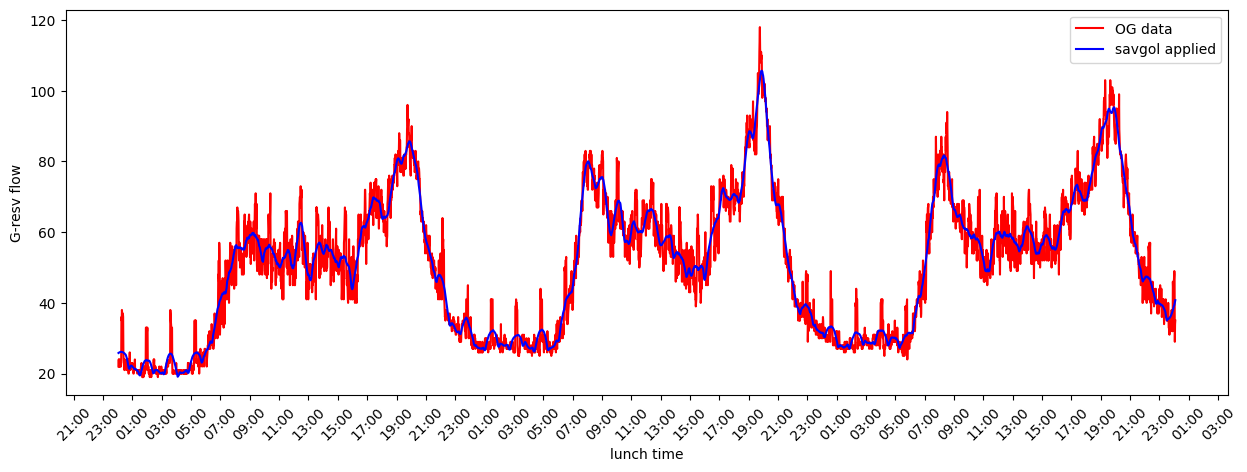

In [6]:
fig, ax = plt.subplots(figsize=(15,5))

#=========g_resv_flow
#=========g_resv_flow
#=========g_resv_flow

ax.plot(time, g_resv_flow_temp['g_resv_flow'], label='OG data', color='red')
ax.plot(time, g_resv_flow_temp['savgol_smooth'], label='savgol applied', color='blue')

#=========misc config
#=========misc config
#=========misc config
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('lunch time')
ax.set_ylabel('G-resv flow')
ax.legend()

plt.xticks(rotation=45)

plt.show()

**Learning**

In [7]:
#==========Normalization
#==========Normalization
#==========Normalization
scaler = MinMaxScaler(feature_range=(0,1))

column_to_normalize = g_resv_flow_temp.columns[-1]
g_resv_flow_temp['normalized_flow'] = scaler.fit_transform(g_resv_flow_temp[[column_to_normalize]])


#==========Create Sliding Window Dataset
#==========Create Sliding Window Dataset
#==========Create Sliding Window Dataset
# X.shape = (60,1) y.shape = (10,1) => X는 60분 학습 데이터, y는 10분 예측 데이터. 1분이 1개의 feature로 들어간다.  
def create_sliding_windows(data, window_size=60, lead_time=1, forecast_size=10):
    stop_index = len(data) - window_size - forecast_size
    X = [data[i:i+window_size] for i in range(stop_index)]
    y = [data[i+window_size : i+window_size+forecast_size] for i in range(stop_index)]

    return np.array(X), np.array(y)

g_resv_flow_values = g_resv_flow_temp['normalized_flow'].values
X,y = create_sliding_windows(g_resv_flow_values)
X = X.reshape((X.shape[0], X.shape[1],1))

#==========Train Test Split
#==========Train Test Split
#==========Train Test Split
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


#==========Univariate LSTM with MSE Loss
#==========Univariate LSTM with MSE Loss
#==========Univariate LSTM with MSE Loss
#define model
model = Sequential([
    #1층
    LSTM(units=units, activation='relu', input_shape=(60,1), return_sequences=False), #2층쓸거면 트루
    Dropout(0.2),
    #2층
    #LSTM(units=int(units/2), activation='relu', return_sequences=False),
    #Dropout(0.2),

    #Output = 10분 예측
    Dense(10)
])

#use MSE for loss
model.compile(optimizer='adam', loss='mse')

#train
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size, #train sample/batch size = step per epoch
    validation_data=(X_test,y_test),
    verbose=1
)

y_pred_normalized = model.predict(X_test)

y_pred_original = scaler.inverse_transform(y_pred_normalized.reshape(-1,1).reshape(y_pred_normalized.shape))
y_test_original = scaler.inverse_transform(y_test.reshape(-1,1).reshape(y_test.shape))

mae = mean_absolute_error(y_test_original, y_pred_original)
print(f"--- Evaluation Result ---")
print(f"Mean Absolute Error: {mae:.2f} m^3/hour")
print(f"Interpretation: On average, our 10-minute prediction is off by {mae:.2f} m^3/hour.")

Epoch 1/20


c:\Users\user\miniconda3\envs\mypy\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0299 - val_loss: 0.0018
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0043 - val_loss: 9.0881e-04
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0032 - val_loss: 7.8543e-04
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0028 - val_loss: 5.5242e-04
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0023 - val_loss: 6.4669e-04
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0019 - val_loss: 4.6034e-04
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0019 - val_loss: 8.8715e-04
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0017 - val_loss: 4.6324e-04
Epoch 9/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0016 - val_loss: 6.5632e-04
Epoch 10/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0015 - val_loss: 4.4392e-04
Epoch 11/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0015 - val_loss: 3.9775e-04
Epoch 12/20


**Evaluation**

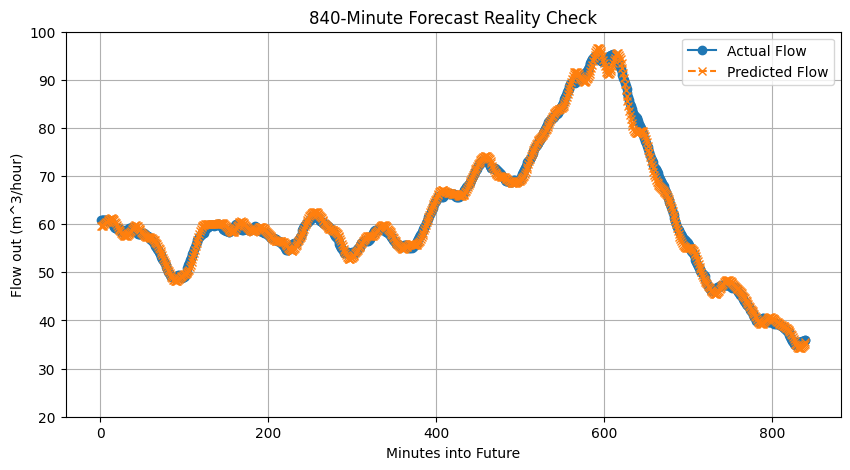

In [8]:
sample_idx0 = 10 * 0
interval = 60 * 14 #Max = total interval (minute) * 0.2
sample_idx1 = sample_idx0 + interval
 
plt.figure(figsize=(10, 5))
plt.plot(range(1, 1+interval), y_test_original[sample_idx0:sample_idx1,0], label='Actual Flow', marker='o')
plt.plot(range(1, 1+interval), y_pred_original[sample_idx0:sample_idx1,0], label='Predicted Flow', marker='x', linestyle='--')
plt.title(f"{interval}-Minute Forecast Reality Check")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow out (m^3/hour)")
plt.legend()
plt.grid(True)
plt.ylim(20, 100) 
plt.show()

**y-값에 대한 설명**
- y는 (10,1) 모양이다. 0~9분의 컬럼이 있고 각 컬럼에는 그 시각에 해당하는 유출유량 정보가 들어있다.

In [9]:
y_test_original[1]

array([60.9218566 , 60.87313936, 60.79224388, 60.83439844, 60.77713386,
       60.8986491 , 60.82489845, 60.82184205, 60.71202318, 60.61333175])

- 0~99분까지의 시간 중에서 0~9분, 10~19분, ... , 90~99분 데이터를 가져와보았다. 9분과 10분, ... , 89분과 90분 데이터 사이의 괴리가 크다.

In [10]:
y_pred_original[:100:10]

array([[59.618515, 59.58279 , 59.58554 , 59.401806, 59.319164, 59.36251 ,
        59.38711 , 59.49667 , 59.40637 , 59.410667],
       [61.0787  , 61.064713, 61.175846, 60.989708, 61.01481 , 61.113495,
        61.20031 , 61.278202, 61.351124, 61.3213  ],
       [59.46876 , 59.4272  , 59.42104 , 59.263927, 59.213398, 59.195633,
        59.24592 , 59.170845, 59.297905, 59.201252],
       [57.58601 , 57.564945, 57.60851 , 57.436684, 57.3709  , 57.42824 ,
        57.49143 , 57.575806, 57.552917, 57.55435 ],
       [59.665295, 59.661613, 59.804184, 59.62585 , 59.66098 , 59.772945,
        59.885937, 59.953205, 60.06775 , 60.038784],
       [57.924637, 57.8943  , 57.910847, 57.75552 , 57.69547 , 57.69801 ,
        57.764824, 57.717773, 57.828922, 57.755184],
       [57.139297, 57.11896 , 57.178608, 57.018578, 56.981926, 57.02756 ,
        57.111107, 57.135258, 57.20129 , 57.173553],
       [54.77095 , 54.73623 , 54.728806, 54.59439 , 54.51801 , 54.489975,
        54.563892, 54.48812 , 54.5926

- 0~9분까지의 데이터를 가져와보았다. 각 row의 첫번째 컬럼은 0분, 1분, ..., 9분을 의미한다. 이 데이터들 사이에는 괴리가 적다.

In [11]:
y_pred_original[:10]

array([[59.618515, 59.58279 , 59.58554 , 59.401806, 59.319164, 59.36251 ,
        59.38711 , 59.49667 , 59.40637 , 59.410667],
       [59.642735, 59.611427, 59.632294, 59.446255, 59.3752  , 59.4339  ,
        59.466522, 59.591946, 59.501724, 59.513763],
       [59.72497 , 59.697983, 59.736885, 59.548775, 59.490555, 59.563484,
        59.604385, 59.741886, 59.65677 , 59.673958],
       [59.849903, 59.826553, 59.88197 , 59.692497, 59.647804, 59.732204,
        59.781284, 59.92467 , 59.85074 , 59.86949 ],
       [60.00205 , 59.981495, 60.05106 , 59.861057, 59.829994, 59.922432,
        59.979248, 60.121822, 60.064865, 60.08147 ],
       [60.179848, 60.16197 , 60.244278, 60.05381 , 60.03539 , 60.13454 ,
        60.198574, 60.33815 , 60.299625, 60.312546],
       [60.363514, 60.347427, 60.439907, 60.24968 , 60.243103, 60.345955,
        60.41644 , 60.54804 , 60.53115 , 60.537815],
       [60.564426, 60.55028 , 60.652046, 60.4617  , 60.465298, 60.571766,
        60.648026, 60.77246 , 60.7755

- 따라서 각 row의 0번째 컬럼 데이터를 이용하면 그래프가 깔끔하게 그려진다.

In [12]:
y_pred_original[:10,0]

array([59.618515, 59.642735, 59.72497 , 59.849903, 60.00205 , 60.179848,
       60.363514, 60.564426, 60.75678 , 60.93476 ], dtype=float32)